# CSE457 - Lab 1: Phân tích và xử lý tín hiệu âm thanh số

In [1]:
from pathlib import Path
from math import gcd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

INPUT_PATH = Path("audio/input/lab1_input_stereo_44k1.wav")
FIG_DIR = Path("figures")
FILTER_DIR = Path("audio/filtered")
QUANT_DIR = Path("audio/quantized")
RESAMPLE_DIR = Path("audio/resampled")

for p in [FIG_DIR, FILTER_DIR, QUANT_DIR, RESAMPLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())

Input: audio\input\lab1_input_stereo_44k1.wav
Exists: True


In [2]:
def normalize_pcm(x):
    if np.issubdtype(x.dtype, np.integer):
        info = np.iinfo(x.dtype)
        scale = max(abs(info.min), abs(info.max))
        return x.astype(np.float64) / scale
    return x.astype(np.float64)

def rms(x):
    return np.sqrt(np.mean(np.asarray(x, dtype=np.float64)**2))

def energy(x):
    x = np.asarray(x, dtype=np.float64)
    return np.sum(x**2)

def save_wav16(path, x, fs):
    x = np.clip(x, -1, 1)
    wavfile.write(path, fs, np.int16(np.round(x * 32767)))

def get_segment(x, fs, start, end):
    return x[int(start*fs):int(end*fs)]

def snr_db(x, xq):
    e = xq - x
    return 10*np.log10(np.sum(x*x) / np.sum(e*e))

## A. Đọc và kiểm tra dữ liệu âm thanh

Với tín hiệu số: \(x[n] = x_a(nT)\), \(F_s = 1/T\).

Cần kiểm tra sampling rate, số kênh, thời lượng, bit depth và kích thước file. Nếu stereo thì chuyển về mono bằng trung bình hai kênh.

In [3]:
Fs, raw = wavfile.read(INPUT_PATH)

channels = 1 if raw.ndim == 1 else raw.shape[1]
duration = raw.shape[0] / Fs
bit_depth = raw.dtype.itemsize * 8
file_size = INPUT_PATH.stat().st_size

x_all = normalize_pcm(raw)

if channels == 2:
    left = x_all[:, 0]
    right = x_all[:, 1]
    x = (left + right) / 2
else:
    left = x_all
    right = None
    x = x_all

print(f"Sampling rate : {Fs} Hz")
print(f"Channels      : {channels}")
print(f"Duration      : {duration:.3f} s")
print(f"Bit depth     : {bit_depth} bit/sample")
print(f"File size     : {file_size/1024**2:.3f} MiB")
print(f"Samples       : {len(x)}")
print(f"Mono min/max  : {x.min():.4f} / {x.max():.4f}")

if channels == 2:
    print(f"RMS Left      : {rms(left):.4f}")
    print(f"RMS Right     : {rms(right):.4f}")
print(f"RMS Mono      : {rms(x):.4f}")

save_wav16("audio/input/input_mono.wav", x, Fs)

Sampling rate : 44100 Hz
Channels      : 2
Duration      : 12.000 s
Bit depth     : 16 bit/sample
File size     : 2.019 MiB
Samples       : 529200
Mono min/max  : -0.7190 / 0.7380
RMS Left      : 0.3824
RMS Right     : 0.3576
RMS Mono      : 0.3422


**Nhận xét:** File mẫu có 44.1 kHz, stereo, 16 bit và dài 12 s. Sau khi chuyển mono, RMS giảm nhẹ do hai kênh có biên độ/pha khác nhau. Tín hiệu đã được chuẩn hóa về khoảng `[-1, 1]`.

## B. Phân tích miền thời gian

\[
Peak=\max |x[n]|,\quad
RMS=\sqrt{\frac{1}{N}\sum x^2[n]},\quad
E=\sum x^2[n]
\]

In [4]:
peak = np.max(np.abs(x))
rms_x = rms(x)
energy_x = energy(x)
num_clipped = np.sum(np.abs(x) >= 0.999)

print(f"Peak      : {peak:.6f}")
print(f"RMS       : {rms_x:.6f}")
print(f"Energy    : {energy_x:.2f}")
print(f"Clipped samples (>=0.999): {num_clipped}")

Peak      : 0.738022
RMS       : 0.342194
Energy    : 61967.41
Clipped samples (>=0.999): 0


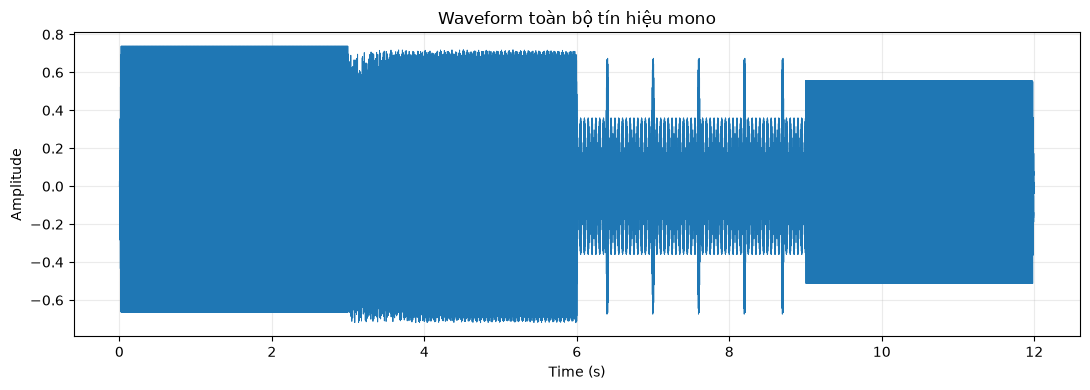

In [5]:
t = np.arange(len(x)) / Fs
plt.figure(figsize=(11, 4))
plt.plot(t, x, linewidth=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform toàn bộ tín hiệu mono")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "waveform_full.png", dpi=150)
plt.show()

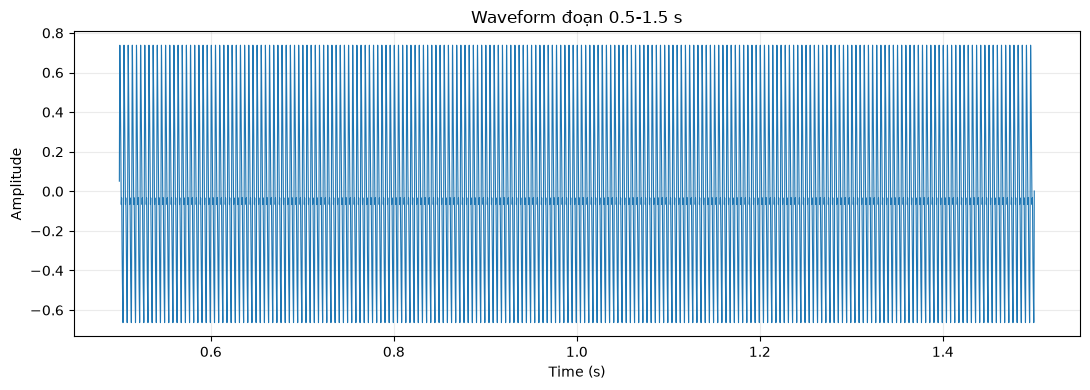

Đoạn 0.5-1.5 s: Peak=0.7380, RMS=0.4358, Energy=8376.57
Đoạn 6.0-7.0 s: Peak=0.6740, RMS=0.1861, Energy=1527.11


In [6]:
start, end = 0.5, 1.5
seg = get_segment(x, Fs, start, end)
tt = np.arange(len(seg))/Fs + start

plt.figure(figsize=(11, 4))
plt.plot(tt, seg, linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform đoạn 0.5-1.5 s")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "waveform_zoom.png", dpi=150)
plt.show()

seg2 = get_segment(x, Fs, 6.0, 7.0)
print(f"Đoạn 0.5-1.5 s: Peak={np.max(np.abs(seg)):.4f}, RMS={rms(seg):.4f}, Energy={energy(seg):.2f}")
print(f"Đoạn 6.0-7.0 s: Peak={np.max(np.abs(seg2)):.4f}, RMS={rms(seg2):.4f}, Energy={energy(seg2):.2f}")

**Nhận xét:** Peak của toàn tín hiệu khoảng 0.738 và không có mẫu chạm mức 0.999 nên chưa có clipping. Đoạn 0.5-1.5 s có RMS lớn hơn đoạn 6-7 s, nghĩa là mức năng lượng trung bình cao hơn.

## C. Phân tích miền tần số bằng FFT

Khoảng cách giữa các bin:

\[
\Delta f = \frac{F_s}{NFFT}
\]

Tăng NFFT làm các điểm trên trục tần số dày hơn nhưng không tự tạo thêm thông tin mới.

NFFT=65536, Δf=0.672913 Hz


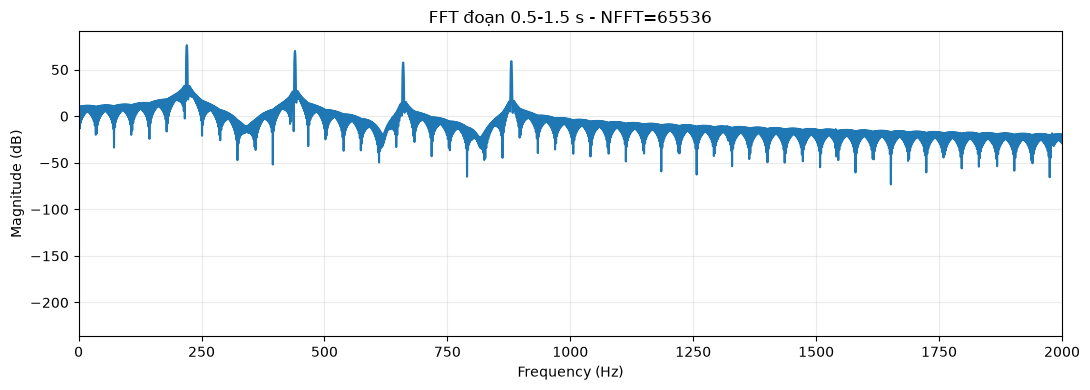

NFFT=131072, Δf=0.336456 Hz


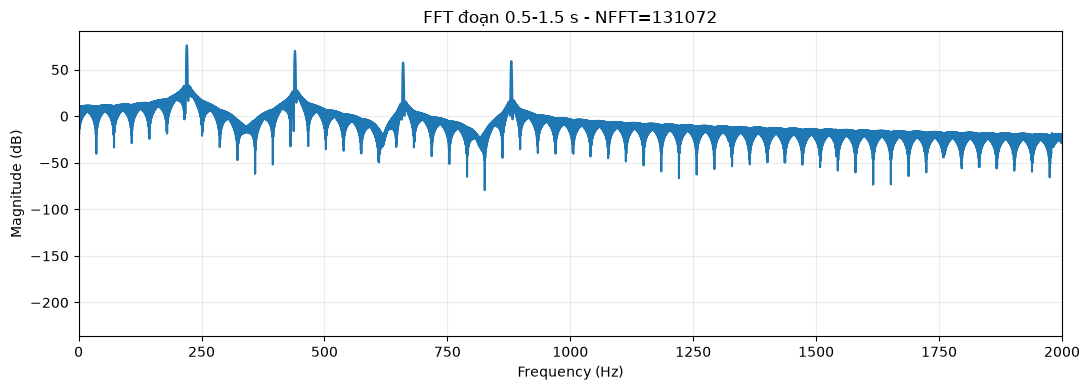

Các peak nổi bật:
220.04 Hz
440.08 Hz
879.83 Hz
660.13 Hz
224.42 Hz


In [7]:
fft_seg = get_segment(x, Fs, 0.5, 1.5)
w = np.hamming(len(fft_seg))

for NFFT in [65536, 131072]:
    X = np.fft.rfft(fft_seg*w, n=NFFT)
    f = np.fft.rfftfreq(NFFT, 1/Fs)
    mag = np.abs(X)
    db = 20*np.log10(np.maximum(mag, 1e-12))

    print(f"NFFT={NFFT}, Δf={Fs/NFFT:.6f} Hz")

    plt.figure(figsize=(11, 4))
    plt.plot(f, db)
    plt.xlim(0, 2000)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"FFT đoạn 0.5-1.5 s - NFFT={NFFT}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fft_{NFFT}.png", dpi=150)
    plt.show()

# tìm các peak nổi bật ở NFFT lớn
NFFT = 131072
X = np.fft.rfft(fft_seg*w, n=NFFT)
f = np.fft.rfftfreq(NFFT, 1/Fs)
mag = np.abs(X)
idx, _ = signal.find_peaks(mag)
valid = idx[(f[idx] > 1) & (f[idx] <= 5000)]
top = valid[np.argsort(mag[valid])[-5:]][::-1]

print("Các peak nổi bật:")
for i in top:
    print(f"{f[i]:.2f} Hz")

**Nhận xét:** Khi NFFT tăng từ 65536 lên 131072, \(\Delta f\) giảm từ khoảng 0.673 Hz xuống 0.336 Hz. Các peak chính nằm gần 220, 440, 660 và 880 Hz, thể hiện cấu trúc điều hòa. Frame vẫn dài 1 s nên true resolution không tự tăng chỉ vì zero-padding.

## D. STFT và Spectrogram

STFT cho biết thành phần tần số thay đổi theo thời gian. So sánh frame 10, 25 và 50 ms, giữ hop = 10 ms.

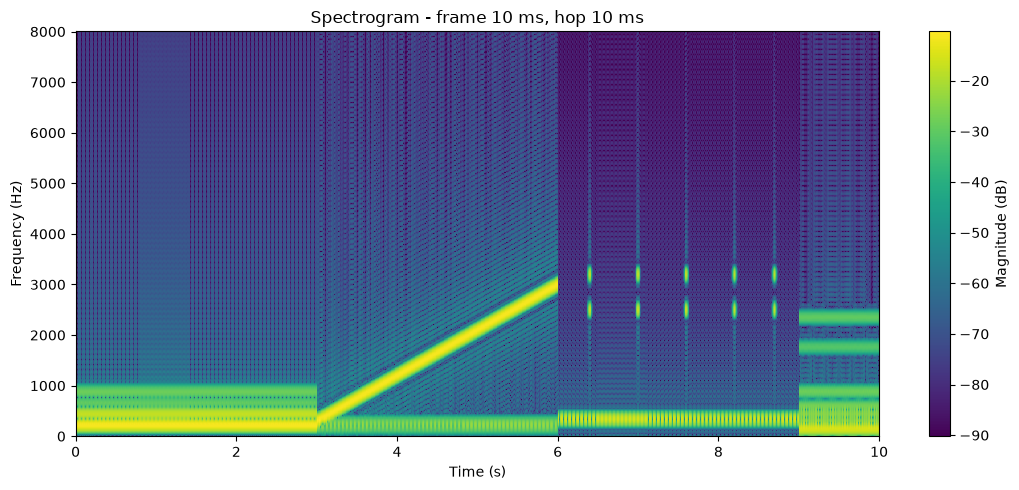

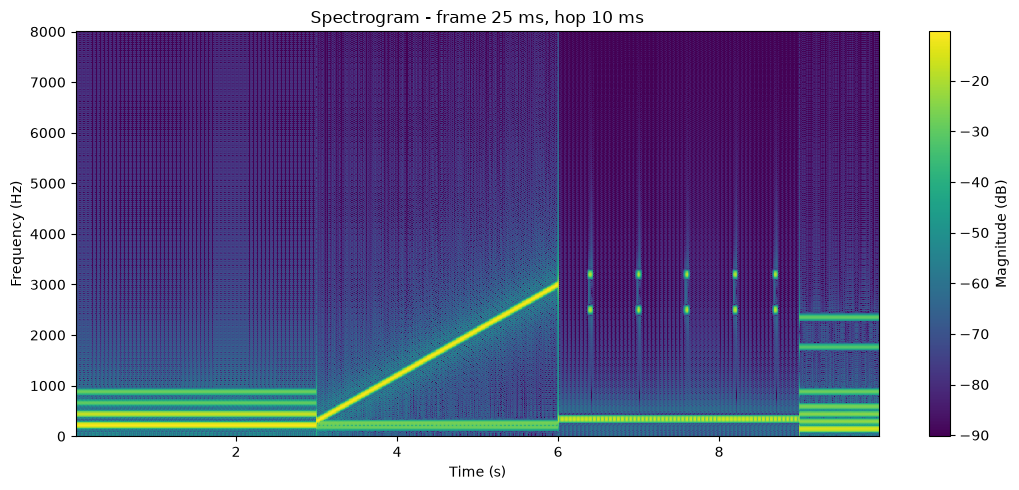

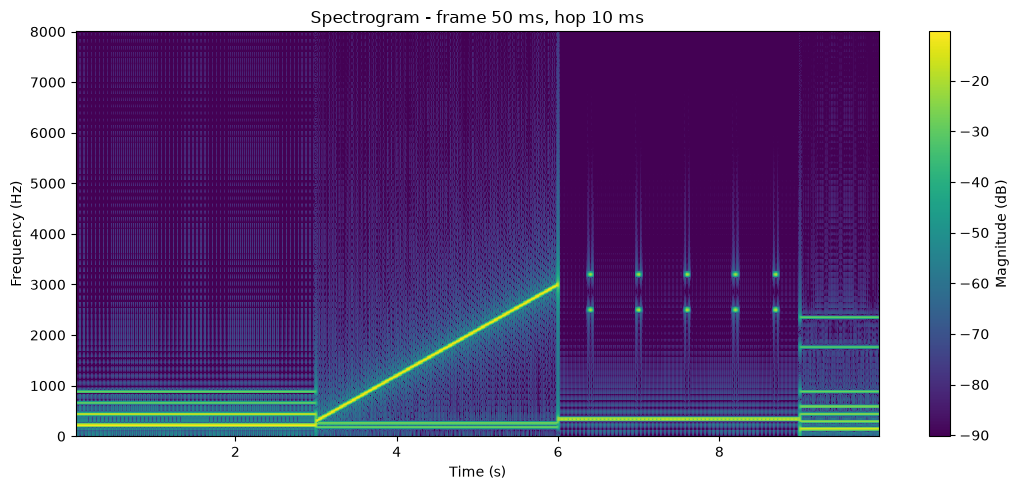

In [8]:
x_stft = get_segment(x, Fs, 0, 10)
frame_ms_list = [10, 25, 50]
hop = round(0.010*Fs)

# cùng color scale để so sánh
results = {}
global_max = -np.inf

for frame_ms in frame_ms_list:
    L = round(frame_ms/1000*Fs)
    noverlap = L - hop
    f_stft, t_stft, Z = signal.stft(
        x_stft, fs=Fs, window="hamming",
        nperseg=L, noverlap=noverlap,
        nfft=4096, boundary=None, padded=False
    )
    S_db = 20*np.log10(np.maximum(np.abs(Z), 1e-12))
    results[frame_ms] = (f_stft, t_stft, S_db)
    global_max = max(global_max, S_db.max())

for frame_ms in frame_ms_list:
    f_stft, t_stft, S_db = results[frame_ms]
    mask = f_stft <= 8000

    plt.figure(figsize=(11, 5))
    plt.pcolormesh(
        t_stft, f_stft[mask], S_db[mask, :],
        shading="auto", vmin=global_max-80, vmax=global_max
    )
    plt.colorbar(label="Magnitude (dB)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Spectrogram - frame {frame_ms} ms, hop 10 ms")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"spectrogram_{frame_ms}ms.png", dpi=150)
    plt.show()

**Nhận xét:** Frame 10 ms thể hiện biến đổi thời gian rõ hơn. Frame 50 ms cho dải tần sắc hơn nhưng làm mờ biến đổi nhanh. Frame 25 ms là mức cân bằng giữa hai loại độ phân giải.

## E. So sánh cửa sổ Rectangular và Hamming

Hamming giúp giảm spectral leakage nhưng main-lobe rộng hơn rectangular.

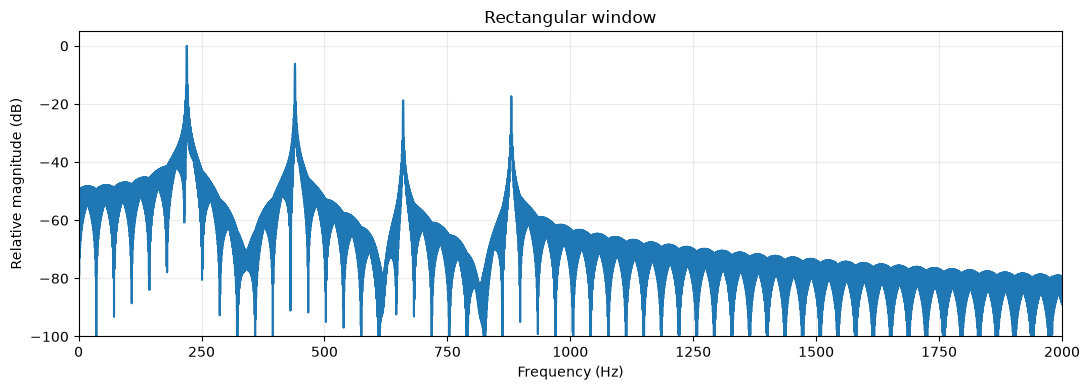

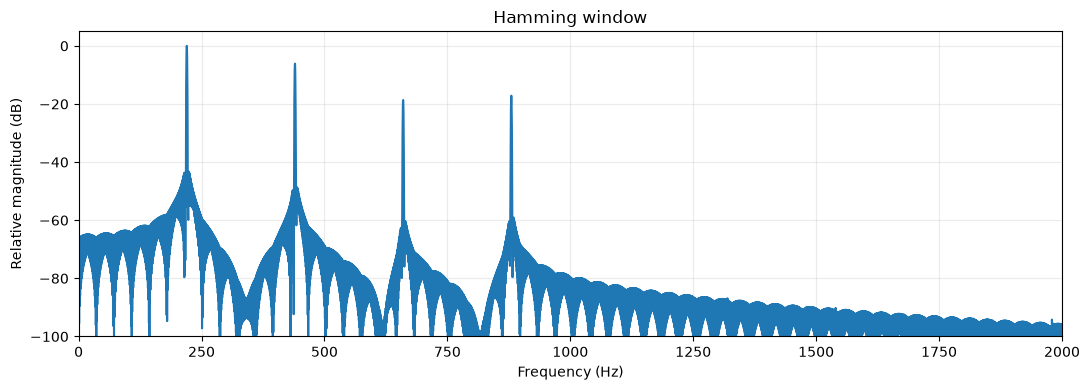

In [9]:
seg = get_segment(x, Fs, 0.5, 1.5)
NFFT = 131072

for name, win in [
    ("Rectangular", np.ones(len(seg))),
    ("Hamming", np.hamming(len(seg)))
]:
    X = np.fft.rfft(seg*win, n=NFFT)
    f = np.fft.rfftfreq(NFFT, 1/Fs)
    db = 20*np.log10(np.maximum(np.abs(X), 1e-12))
    db = db - db.max()

    plt.figure(figsize=(11, 4))
    plt.plot(f, db)
    plt.xlim(0, 2000)
    plt.ylim(-100, 5)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Relative magnitude (dB)")
    plt.title(f"{name} window")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"window_{name.lower()}.png", dpi=150)
    plt.show()

**Nhận xét:** Rectangular có side-lobe cao nên leakage rõ hơn. Hamming giảm side-lobe và làm phổ sạch hơn, đổi lại main-lobe rộng hơn.

## F. Lọc số FIR

Thiết kế FIR low-pass 2 kHz và high-pass 1 kHz, 201 taps, cửa sổ Hamming.

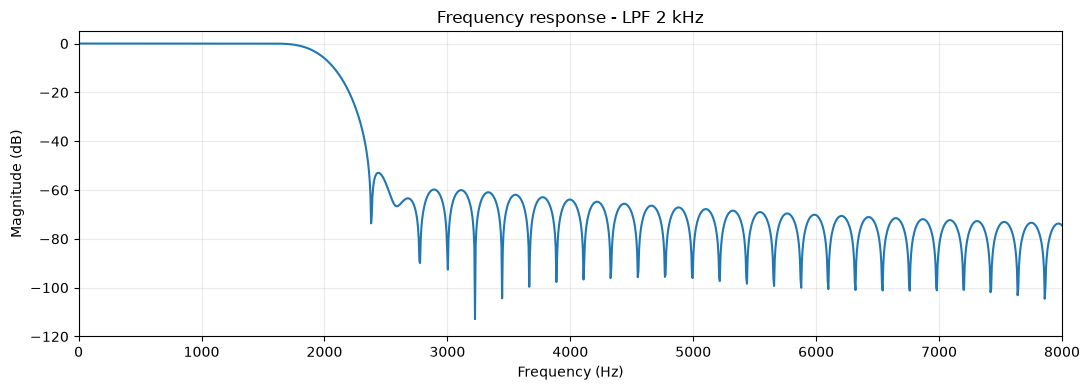

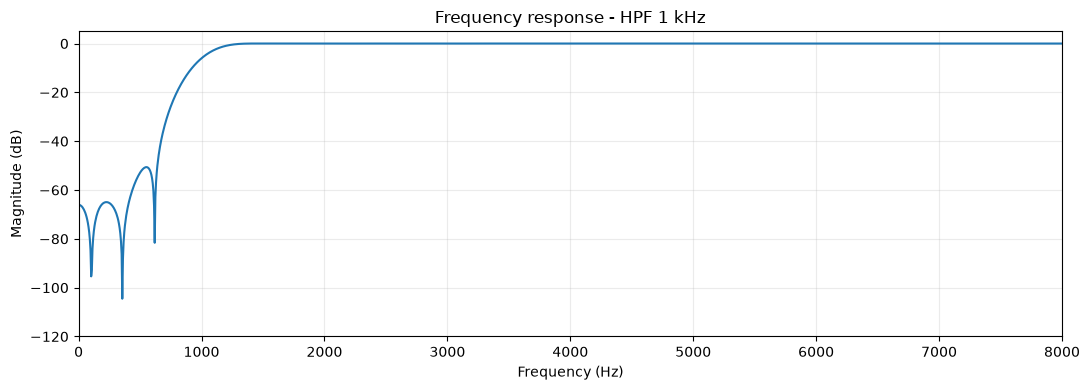

Group delay ≈ 100 samples = 2.268 ms


In [10]:
numtaps = 201
b_lp = signal.firwin(numtaps, 2000, fs=Fs, window="hamming")
b_hp = signal.firwin(numtaps, 1000, fs=Fs, window="hamming", pass_zero=False)

for name, b in [("LPF 2 kHz", b_lp), ("HPF 1 kHz", b_hp)]:
    f_resp, H = signal.freqz(b, worN=4096, fs=Fs)

    plt.figure(figsize=(11, 4))
    plt.plot(f_resp, 20*np.log10(np.maximum(np.abs(H), 1e-12)))
    plt.xlim(0, 8000)
    plt.ylim(-120, 5)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"Frequency response - {name}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"filter_{name.split()[0].lower()}.png", dpi=150)
    plt.show()

y_lp = signal.lfilter(b_lp, [1.0], x)
y_hp = signal.lfilter(b_hp, [1.0], x)

save_wav16(FILTER_DIR / "input_lpf_2k.wav", y_lp, Fs)
save_wav16(FILTER_DIR / "input_hpf_1k.wav", y_hp, Fs)

delay_samples = (numtaps-1)/2
print(f"Group delay ≈ {delay_samples:.0f} samples = {delay_samples/Fs*1000:.3f} ms")

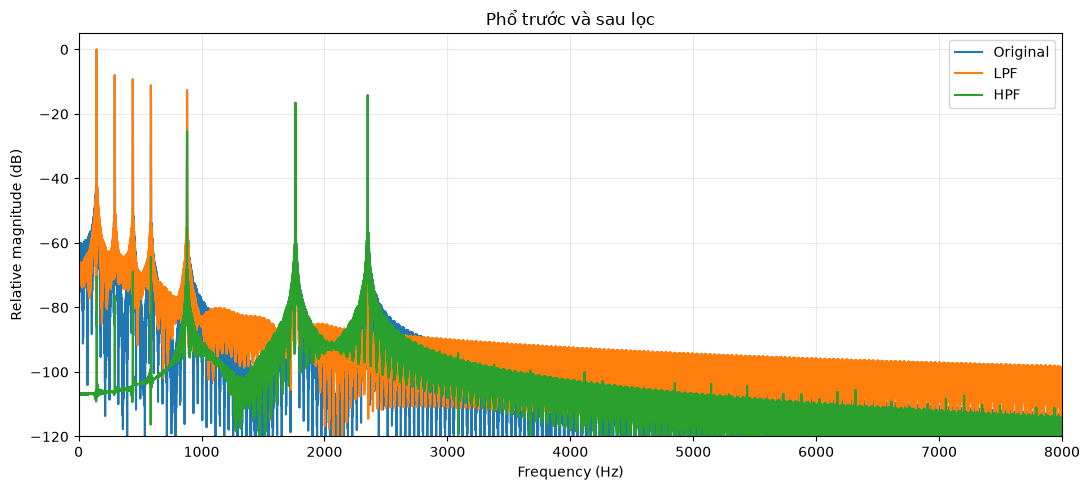

In [11]:
start, end = 9.0, 10.0
signals = [
    ("Original", get_segment(x, Fs, start, end)),
    ("LPF", get_segment(y_lp, Fs, start, end)),
    ("HPF", get_segment(y_hp, Fs, start, end))
]

ref_max = None
spectra = []

for name, s in signals:
    W = np.hamming(len(s))
    X = np.fft.rfft(s*W, n=65536)
    f = np.fft.rfftfreq(65536, 1/Fs)
    db = 20*np.log10(np.maximum(np.abs(X), 1e-12))
    if ref_max is None:
        ref_max = db.max()
    spectra.append((name, f, db-ref_max))

plt.figure(figsize=(11, 5))
for name, f, db in spectra:
    plt.plot(f, db, label=name)
plt.xlim(0, 8000)
plt.ylim(-120, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative magnitude (dB)")
plt.title("Phổ trước và sau lọc")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "filter_before_after.png", dpi=150)
plt.show()

**Nhận xét:** LPF giữ phần thấp và giảm mạnh tần số trên 2 kHz. HPF giảm vùng dưới 1 kHz. Với 201 taps, group delay khoảng 100 mẫu, tương đương 2.27 ms tại 44.1 kHz.

## G. Lượng tử hóa, resampling và mã hóa

 4 bit ->    16 mức, SNR = 18.42 dB
 8 bit ->   256 mức, SNR = 43.48 dB
16 bit -> 65536 mức, SNR = 91.78 dB


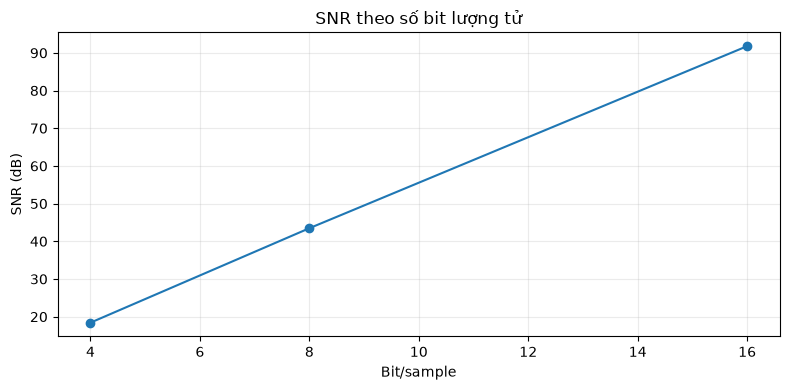

In [12]:
def quantize(x, B):
    qmax = 2**(B-1) - 1
    return np.round(np.clip(x, -1, 1)*qmax) / qmax

bits = [4, 8, 16]
snr_values = []

for B in bits:
    xq = quantize(x, B)
    s = snr_db(x, xq)
    snr_values.append(s)
    save_wav16(QUANT_DIR / f"input_{B}bit.wav", xq, Fs)
    print(f"{B:2d} bit -> {2**B:5d} mức, SNR = {s:.2f} dB")

plt.figure(figsize=(8, 4))
plt.plot(bits, snr_values, marker="o")
plt.xlabel("Bit/sample")
plt.ylabel("SNR (dB)")
plt.title("SNR theo số bit lượng tử")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "quantization_snr.png", dpi=150)
plt.show()

In [13]:
def resample_to(x, fs_old, fs_new):
    g = gcd(fs_old, fs_new)
    return signal.resample_poly(x, fs_new//g, fs_old//g)

for fs_new in [16000, 8000]:
    xr = resample_to(x, Fs, fs_new)
    save_wav16(RESAMPLE_DIR / f"input_{fs_new//1000}k.wav", xr, fs_new)
    print(
        f"{fs_new} Hz -> {len(xr)} samples, "
        f"duration={len(xr)/fs_new:.2f} s, Nyquist={fs_new/2:.0f} Hz"
    )

16000 Hz -> 192000 samples, duration=12.00 s, Nyquist=8000 Hz
8000 Hz -> 96000 samples, duration=12.00 s, Nyquist=4000 Hz


In [14]:
pcm_bitrate = Fs * bit_depth * channels
pcm_size = pcm_bitrate * duration / 8

print(f"PCM bitrate = {pcm_bitrate/1000:.1f} kbps")
print(f"PCM size lý thuyết = {pcm_size/1e6:.3f} MB")

for mp3_kbps in [128, 256]:
    compressed_size = mp3_kbps*1000*duration/8
    ratio = pcm_bitrate/(mp3_kbps*1000)
    saving = (1-compressed_size/pcm_size)*100
    print(
        f"MP3 {mp3_kbps} kbps: size≈{compressed_size/1e6:.3f} MB, "
        f"ratio≈{ratio:.2f}:1, saving≈{saving:.2f}%"
    )

PCM bitrate = 1411.2 kbps
PCM size lý thuyết = 2.117 MB
MP3 128 kbps: size≈0.192 MB, ratio≈11.03:1, saving≈90.93%
MP3 256 kbps: size≈0.384 MB, ratio≈5.51:1, saving≈81.86%


**Nhận xét:** SNR tăng rõ khi số bit tăng: khoảng 18.42 dB ở 4 bit, 43.48 dB ở 8 bit và 91.78 dB ở 16 bit. Resampling xuống 16 kHz và 8 kHz vẫn giữ thời lượng 12 s nhưng giảm Nyquist xuống 8 kHz và 4 kHz. PCM stereo 44.1 kHz 16-bit có bitrate 1411.2 kbps; so với MP3 128 kbps, tỷ lệ nén lý thuyết khoảng 11:1.